# Enron Email Network – Task 1: Network Construction & Structural Characterisation
**Filtering method:** K-core decomposition (`k = 5`)  
**Edge weights:** number of emails sent between each pair of accounts  
**Self-loops removed** – emails sent to oneself are system artefacts, not communication events.

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from collections import Counter

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})


## 1. Load Data & Build Full Graph

In [7]:
edges_df = pd.read_csv('enron_weighted_edges.csv')
mapping_df = pd.read_csv('id_mapping.csv')          # Email_Address, ID

# Remove self-loops (node emailing itself – system artefacts)
edges_df = edges_df[edges_df['Source'] != edges_df['Target']].copy()

G_full = nx.from_pandas_edgelist(
    edges_df, source='Source', target='Target',
    edge_attr='Weight', create_using=nx.DiGraph()
)

print(f'Full network : {G_full.number_of_nodes():,} nodes  |  {G_full.number_of_edges():,} edges')


Full network : 56,595 nodes  |  226,837 edges


## 2. K-core Scan – Choose k

In [3]:
G_und = G_full.to_undirected()   # k_core requires undirected graph

print(f'{'k':>4}  {'Nodes':>8}  {'Edges':>9}')
print('-' * 28)
for k in range(2, 30):
    core = nx.k_core(G_und, k=k)
    n, e = core.number_of_nodes(), core.number_of_edges()
    print(f'{k:>4}  {n:>8,}  {e:>9,}')
    if n == 0:
        break


   k     Nodes      Edges
----------------------------
   2    21,183    174,161
   3    13,817    159,645
   4    10,844    150,906
   5     9,066    143,948
   6     7,908    138,284
   7     7,037    133,155
   8     6,395    128,748
   9     5,622    122,736
  10     5,202    119,007
  11     4,790    115,073
  12     4,432    111,294
  13     4,148    107,908
  14     3,849    104,116
  15     3,653    101,387
  16     3,467     98,606
  17     3,255     95,246
  18     3,060     91,950
  19     2,908     89,224
  20     2,738     86,006
  21     2,574     82,735
  22     2,420     79,522
  23     2,270     76,491
  24     2,179     74,418
  25     2,069     71,793
  26     1,980     69,588
  27     1,884     67,169
  28     1,765     63,989
  29     1,672     61,404


## 3. Build K-core Subgraph (k = 5)

In [4]:
CHOSEN_K = 5   # ← change if needed after reviewing the scan above

kcore_nodes = nx.k_core(G_und, k=CHOSEN_K).nodes()
G = G_full.subgraph(kcore_nodes).copy()

# Add distance attribute for weighted centrality (1/weight = short = frequent)
for u, v, d in G.edges(data=True):
    d['distance'] = 1.0 / d['Weight']

print(f'K-core (k={CHOSEN_K}) subgraph: {G.number_of_nodes():,} nodes  |  {G.number_of_edges():,} edges')


K-core (k=5) subgraph: 9,066 nodes  |  160,005 edges


## 4. Network Statistics

In [5]:
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()

# Clustering coefficient (undirected version for interpretability)
avg_clustering = nx.average_clustering(G)

# Network diameter – computed on the largest WCC to avoid inf
G_und_sub = G.to_undirected()
largest_wcc = max(nx.connected_components(G_und_sub), key=len)
G_wcc = G_und_sub.subgraph(largest_wcc)
diameter = nx.diameter(G_wcc)

# Degree (directed: in+out counted once per edge at each end)
degrees = [d for _, d in G.degree()]
avg_degree = np.mean(degrees)

# Weighted degree (sum of weights)
weighted_degrees = [sum(d['Weight'] for _, _, d in G.edges(n, data=True)) +
                    sum(d['Weight'] for _, _, d in G.in_edges(n, data=True))
                    for n in G.nodes()]
avg_weighted_degree = np.mean(weighted_degrees)

# Density
density = nx.density(G)

# Weighted density
total_weight = sum(d['Weight'] for _, _, d in G.edges(data=True))
max_possible  = n_nodes * (n_nodes - 1)   # directed
weighted_density = total_weight / max_possible

# Connected components
n_wcc = nx.number_weakly_connected_components(G)
n_scc = nx.number_strongly_connected_components(G)

# ── Print summary table ──────────────────────────────────────────────────
stats = [
    ('Number of Nodes',                    f'{n_nodes:,}'),
    ('Number of Edges',                    f'{n_edges:,}'),
    ('Average Clustering Coefficient',     f'{avg_clustering:.4f}'),
    ('Network Diameter (largest WCC)',     f'{diameter}'),
    ('Average Degree',                     f'{avg_degree:.2f}'),
    ('Average Weighted Degree',            f'{avg_weighted_degree:.2f}'),
    ('Network Density',                    f'{density:.6f}'),
    ('Weighted Network Density',           f'{weighted_density:.6f}'),
    ('Weakly Connected Components',        f'{n_wcc:,}'),
    ('Strongly Connected Components',      f'{n_scc:,}'),
]

print(f'{'Metric':<40} {'Value':>15}')
print('─' * 57)
for label, val in stats:
    print(f'{label:<40} {val:>15}')


Metric                                             Value
─────────────────────────────────────────────────────────
Number of Nodes                                    9,066
Number of Edges                                  160,005
Average Clustering Coefficient                    0.3034
Network Diameter (largest WCC)                         8
Average Degree                                     35.30
Average Weighted Degree                           178.49
Network Density                                 0.001947
Weighted Network Density                        0.009845
Weakly Connected Components                            1
Strongly Connected Components                      4,688


## 5. Degree Distributions

Average In-Degree  : 17.65
Average Out-Degree : 17.65
Max In-Degree      : 495
Max Out-Degree     : 1024


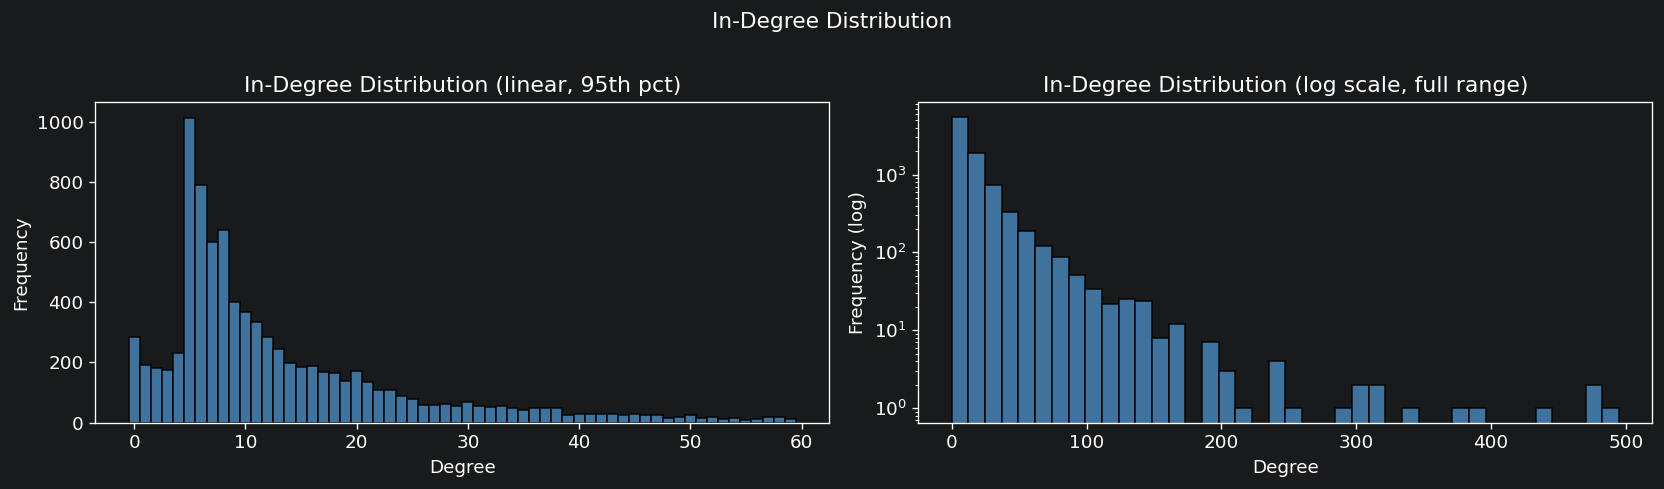

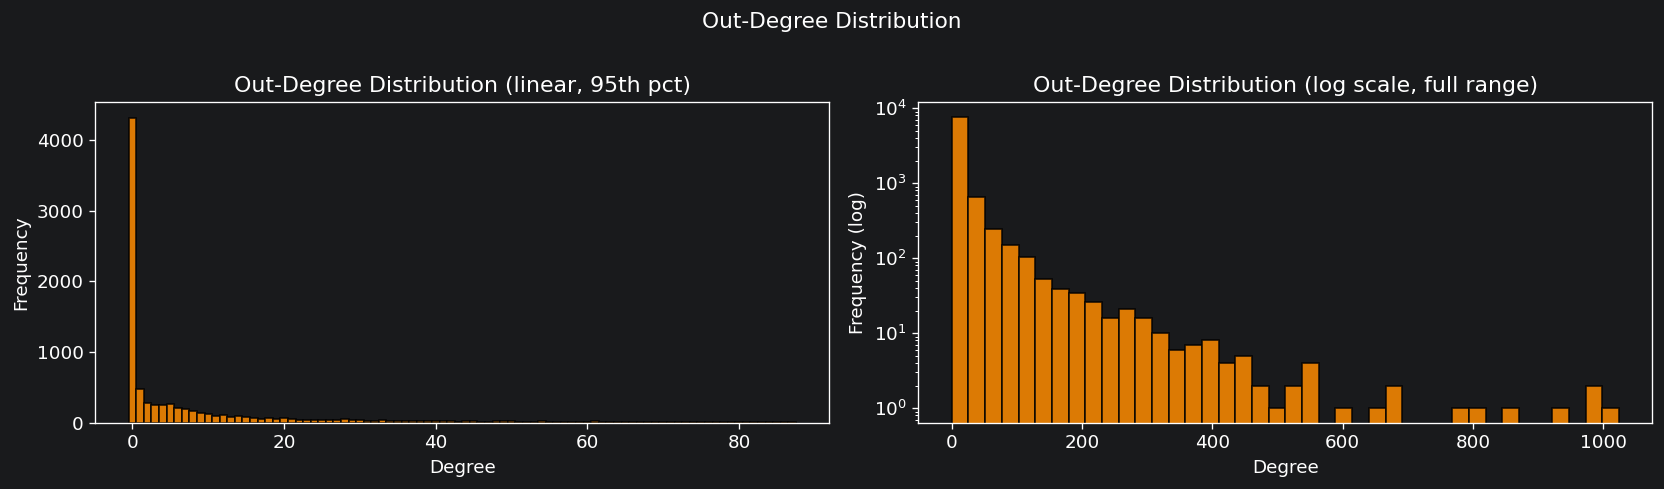

In [6]:
in_degrees  = [d for _, d in G.in_degree()]
out_degrees = [d for _, d in G.out_degree()]

print(f'Average In-Degree  : {np.mean(in_degrees):.2f}')
print(f'Average Out-Degree : {np.mean(out_degrees):.2f}')
print(f'Max In-Degree      : {max(in_degrees)}')
print(f'Max Out-Degree     : {max(out_degrees)}')

def plot_degree_dist(data, title, colour, pct=0.95):
    data = np.array(data)
    x_max = int(np.ceil(np.quantile(data, pct)))
    x_max = max(x_max, int(data.min()) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Linear histogram
    bins = np.arange(data.min(), x_max + 2) - 0.5
    axes[0].hist(data, bins=bins, color=colour, edgecolor='black', alpha=0.85)
    axes[0].set_title(f'{title} (linear, 95th pct)')
    axes[0].set_xlabel('Degree')
    axes[0].set_ylabel('Frequency')

    # Log-scale histogram
    axes[1].hist(data, bins=40, color=colour, edgecolor='black', alpha=0.85)
    axes[1].set_yscale('log')
    axes[1].set_title(f'{title} (log scale, full range)')
    axes[1].set_xlabel('Degree')
    axes[1].set_ylabel('Frequency (log)')

    plt.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

plot_degree_dist(in_degrees,  'In-Degree Distribution',  'steelblue')
plot_degree_dist(out_degrees, 'Out-Degree Distribution', 'darkorange')


## 6. Betweenness Centrality

In [7]:
print('Computing betweenness centrality … (may take a minute)')
betweenness = nx.betweenness_centrality(G, weight='distance')
print('Done.')

bt_df = pd.DataFrame({
    'Node_ID':     list(betweenness.keys()),
    'Betweenness': list(betweenness.values()),
    'In_Degree':   [G.in_degree(n)  for n in betweenness],
    'Out_Degree':  [G.out_degree(n) for n in betweenness],
})
bt_df = bt_df.merge(mapping_df, left_on='Node_ID', right_on='ID').drop(columns='ID')
bt_df['Total_Degree'] = bt_df['In_Degree'] + bt_df['Out_Degree']

top20_bt = (
    bt_df.sort_values('Betweenness', ascending=False)
    .head(20)
    .reset_index(drop=True)
)
top20_bt.index += 1   # rank from 1

print('\n─── Top 20 Nodes by Betweenness Centrality ───')
print(top20_bt[['Email_Address', 'Node_ID', 'Betweenness',
                'In_Degree', 'Out_Degree', 'Total_Degree']].to_string())


Computing betweenness centrality … (may take a minute)
Done.

─── Top 20 Nodes by Betweenness Centrality ───
                  Email_Address  Node_ID  Betweenness  In_Degree  Out_Degree  Total_Degree
1       jeff.dasovich@enron.com      585     0.255010        478         783          1261
2          tana.jones@enron.com     4377     0.112113        495         591          1086
3         susan.scott@enron.com     5556     0.091321        127         555           682
4     sara.shackleton@enron.com     4404     0.081260        473         479           952
5       james.steffes@enron.com      802     0.070022        172         207           379
6         mark.taylor@enron.com     3207     0.063355        436         446           882
7     jeffery.fawcett@enron.com    18646     0.062216         32          46            78
8      louise.kitchen@enron.com     1070     0.056581        294         437           731
9     elizabeth.sager@enron.com      609     0.056353        320        

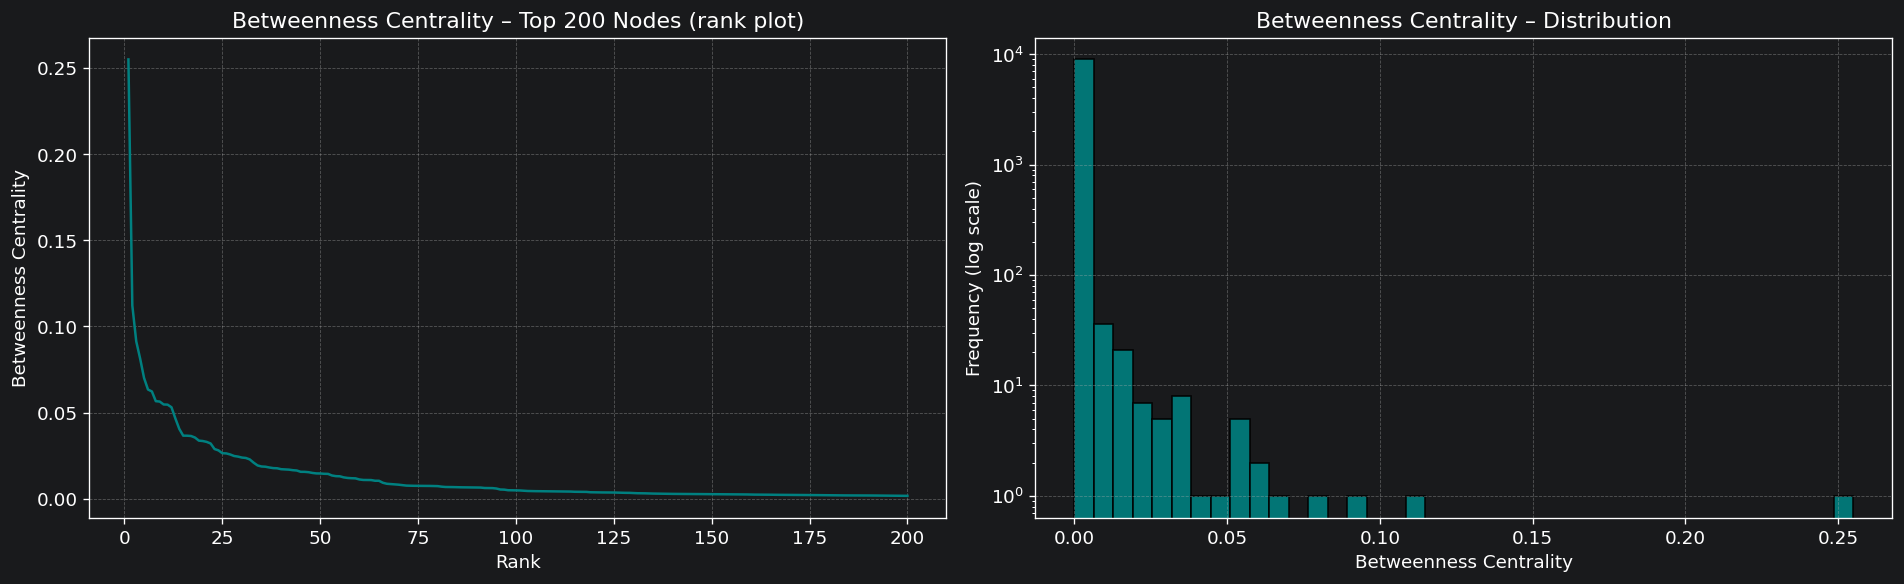

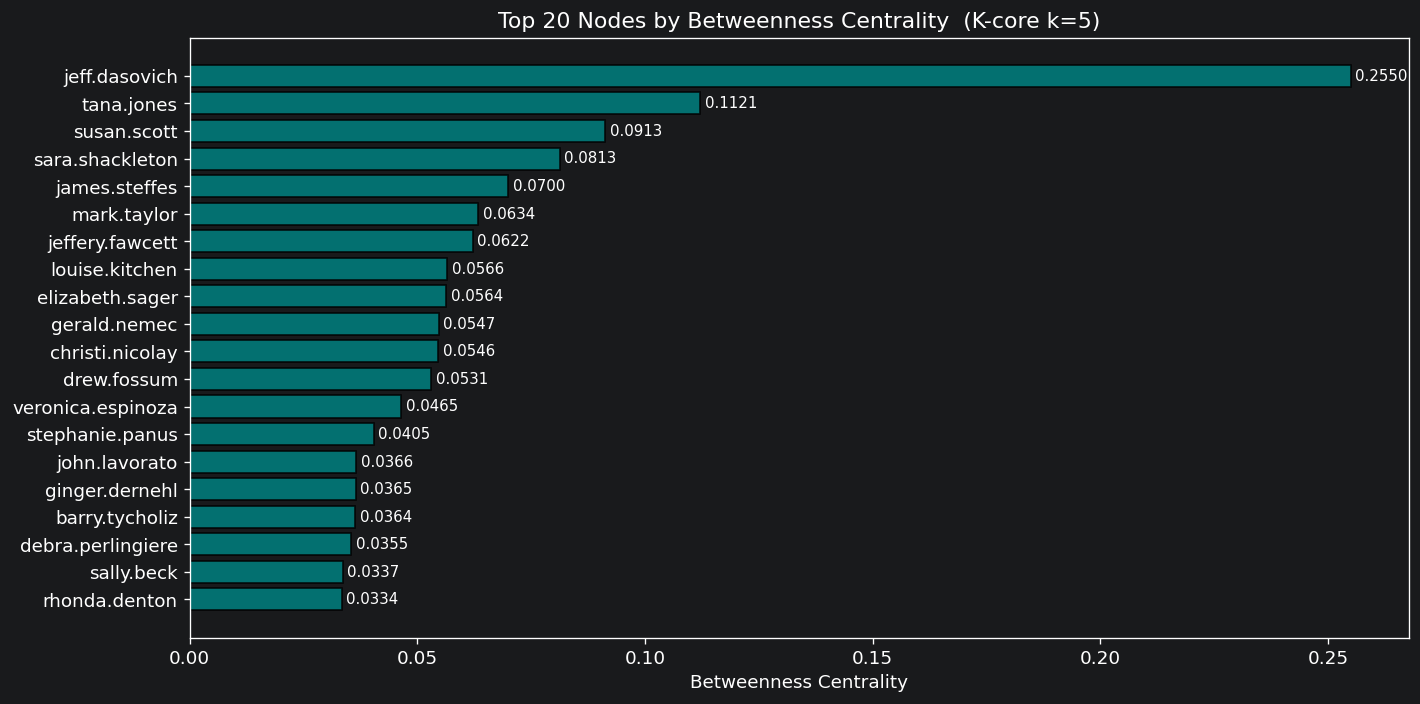

In [8]:
# ── Betweenness visualisations ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Rank plot – top 200
sorted_bt = sorted(betweenness.values(), reverse=True)
axes[0].plot(range(1, 201), sorted_bt[:200], color='teal', linewidth=1.5)
axes[0].set_title('Betweenness Centrality – Top 200 Nodes (rank plot)')
axes[0].set_xlabel('Rank')
axes[0].set_ylabel('Betweenness Centrality')
axes[0].grid(True, linestyle='--', alpha=0.4)

# Distribution
axes[1].hist(list(betweenness.values()), bins=40,
             color='teal', edgecolor='black', alpha=0.9)
axes[1].set_yscale('log')
axes[1].set_title('Betweenness Centrality – Distribution')
axes[1].set_xlabel('Betweenness Centrality')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Top-20 bar chart
fig, ax = plt.subplots(figsize=(12, 6))
labels = [r['Email_Address'].split('@')[0] for _, r in top20_bt.iterrows()]
values = top20_bt['Betweenness'].values
bars = ax.barh(labels[::-1], values[::-1], color='teal', edgecolor='black', alpha=0.85)
ax.set_xlabel('Betweenness Centrality')
ax.set_title(f'Top 20 Nodes by Betweenness Centrality  (K-core k={CHOSEN_K})')
for bar, val in zip(bars, values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


## 7. Closeness Centrality

In [9]:
print('Computing closeness centrality …')
closeness = nx.closeness_centrality(G, distance='distance')
print('Done.')

cl_df = pd.DataFrame({
    'Node_ID':   list(closeness.keys()),
    'Closeness': list(closeness.values()),
    'In_Degree':  [G.in_degree(n)  for n in closeness],
    'Out_Degree': [G.out_degree(n) for n in closeness],
})
cl_df = cl_df.merge(mapping_df, left_on='Node_ID', right_on='ID').drop(columns='ID')
cl_df['Total_Degree'] = cl_df['In_Degree'] + cl_df['Out_Degree']

top20_cl = (
    cl_df.sort_values('Closeness', ascending=False)
    .head(20)
    .reset_index(drop=True)
)
top20_cl.index += 1

print('\n─── Top 20 Nodes by Closeness Centrality ───')
print(top20_cl[['Email_Address', 'Node_ID', 'Closeness',
                'In_Degree', 'Out_Degree', 'Total_Degree']].to_string())


Computing closeness centrality …
Done.

─── Top 20 Nodes by Closeness Centrality ───
                  Email_Address  Node_ID  Closeness  In_Degree  Out_Degree  Total_Degree
1    william.bradford@enron.com      763   0.970310        147          44           191
2          tim.belden@enron.com      521   0.968702        239         173           412
3       john.lavorato@enron.com      998   0.968079        305         387           692
4        edward.sacks@enron.com      783   0.965821        109          75           184
5     lisa.mellencamp@enron.com     3190   0.961144        140          89           229
6         mark.taylor@enron.com     3207   0.961127        436         446           882
7      barry.tycholiz@enron.com     1406   0.960485        189         126           315
8      louise.kitchen@enron.com     1070   0.960372        294         437           731
9     elizabeth.sager@enron.com      609   0.959814        320         251           571
10         ted.murphy@enr

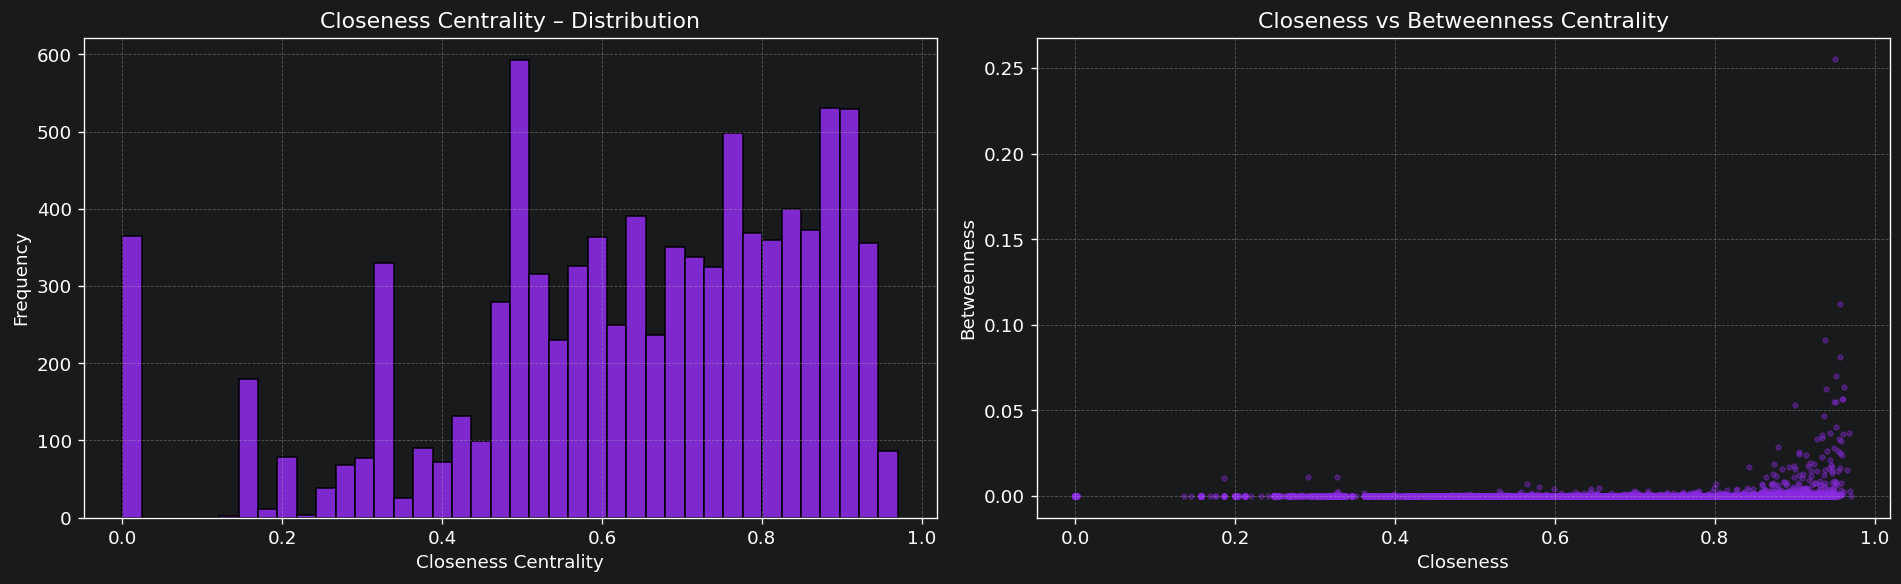

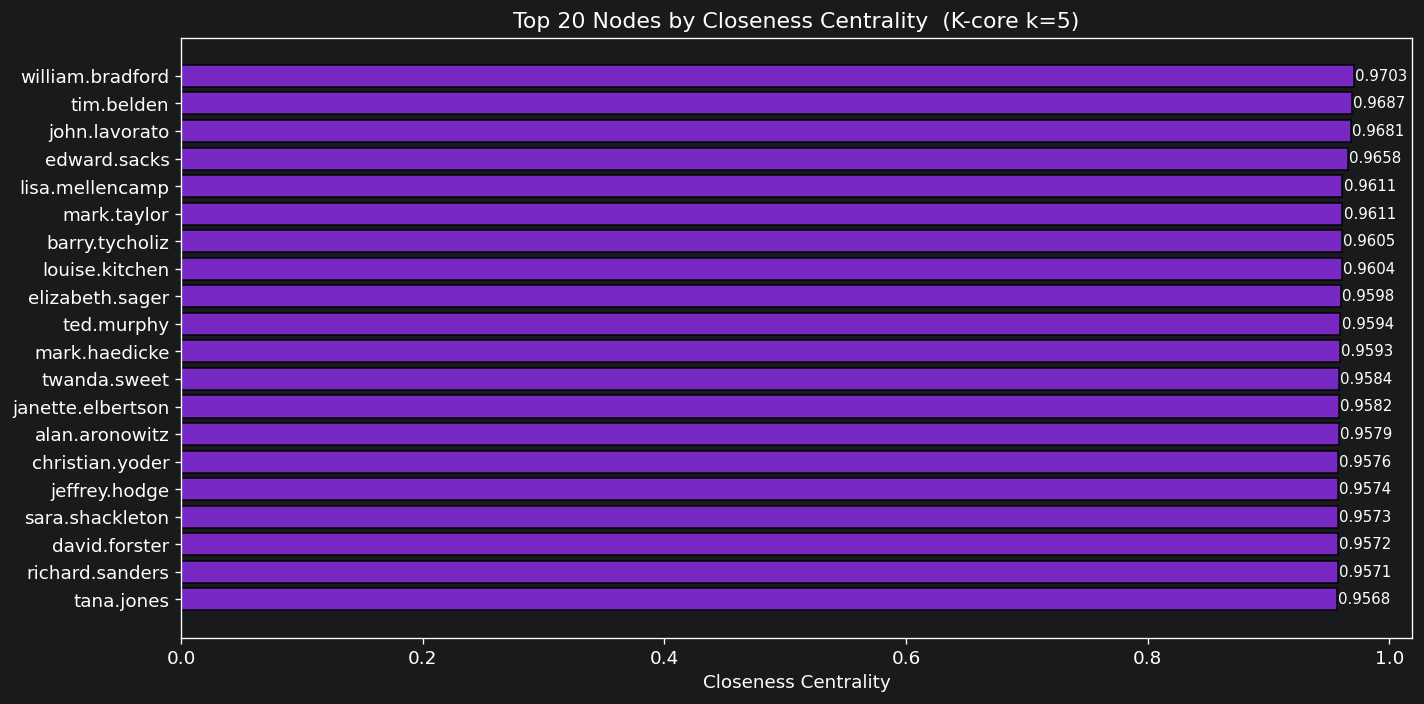

In [10]:
# ── Closeness visualisations ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution
axes[0].hist(list(closeness.values()), bins=40,
             color='blueviolet', edgecolor='black', alpha=0.9)
axes[0].set_title('Closeness Centrality – Distribution')
axes[0].set_xlabel('Closeness Centrality')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, linestyle='--', alpha=0.4)

# Scatter: Closeness vs Betweenness
shared_nodes = list(set(betweenness.keys()) & set(closeness.keys()))
x = [closeness[n] for n in shared_nodes]
y = [betweenness[n] for n in shared_nodes]
axes[1].scatter(x, y, alpha=0.35, s=8, color='blueviolet')
axes[1].set_title('Closeness vs Betweenness Centrality')
axes[1].set_xlabel('Closeness')
axes[1].set_ylabel('Betweenness')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Top-20 bar chart
fig, ax = plt.subplots(figsize=(12, 6))
labels_cl = [r['Email_Address'].split('@')[0] for _, r in top20_cl.iterrows()]
values_cl = top20_cl['Closeness'].values
bars = ax.barh(labels_cl[::-1], values_cl[::-1],
               color='blueviolet', edgecolor='black', alpha=0.85)
ax.set_xlabel('Closeness Centrality')
ax.set_title(f'Top 20 Nodes by Closeness Centrality  (K-core k={CHOSEN_K})')
for bar, val in zip(bars, values_cl[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()
